In [4]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models
from PIL import Image
import matplotlib.pyplot as plt

# Load our split dataset index
df = pd.read_csv("../Dataset/dataset_index_with_splits.csv")
print(df['split'].value_counts())
print(df.head())

split
train    784
test     172
val      168
Name: count, dtype: int64
                                          image_path class_name  class_id  \
0  ../Dataset/Wheat varieties dataset/Dilkash/D12...    Dilkash         1   
1  ../Dataset/Wheat varieties dataset/Dilkash/D12...    Dilkash         1   
2  ../Dataset/Wheat varieties dataset/Dilkash/D12...    Dilkash         1   
3  ../Dataset/Wheat varieties dataset/Dilkash/D15...    Dilkash         1   
4  ../Dataset/Wheat varieties dataset/Dilkash/D15...    Dilkash         1   

  sample_id  split  
0       D12    val  
1       D12    val  
2       D12    val  
3       D15  train  
4       D15  train  


In [6]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label

def make_dataset(split_name, shuffle=False):
    subset = df[df['split'] == split_name]
    paths = subset['image_path'].values
    labels = subset['class_id'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset('train', shuffle=True)
val_ds = make_dataset('val')
test_ds = make_dataset('test')

print("Datasets created successfully.")
for images, labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)

Datasets created successfully.
Batch image shape: (16, 256, 256, 3)
Batch label shape: (16,)


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
])
print("Augmentation layer ready.")

Augmentation layer ready.


In [8]:
base_model = MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

print("Base model loaded successfully.")
print("Number of layers in base model:", len(base_model.layers))
print("Output shape of base model:", base_model.output_shape)

/var/folders/qk/vk69rjr14bn26ykr7clkf9440000gn/T/ipykernel_2050/2042179500.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Base model loaded successfully.
Number of layers in base model: 154
Output shape of base model: (None, 8, 8, 1280)


In [9]:
num_classes = df['class_name'].nunique()

inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = "../models/best_model.keras"

callbacks = [
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [12]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30


/Users/shalinirichhariya/Desktop/Wheat-Image-Classification/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.3852 - loss: 1.3010
Epoch 1: val_accuracy improved from None to 0.53571, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 355ms/step - accuracy: 0.3852 - loss: 1.3010 - val_accuracy: 0.5357 - val_loss: 0.8957
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.4158 - loss: 1.0484
Epoch 2: val_accuracy improved from 0.53571 to 0.61310, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - accuracy: 0.4158 - loss: 1.0484 - val_accuracy: 0.6131 - val_loss: 0.8461
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.4503 - loss: 1.0331
Epoch 3: val_accuracy did not improve from 0.61310
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 338ms/step - accuracy: 0.4503 - loss: 1.0331 - val_accuracy: 0.5595 - val_loss: 0.9612
Epoch 4/30
49/49 ━━━━━━━━━━━━

In [13]:
FINE_TUNE_EPOCHS = 20

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks  # same checkpoint + early stopping as before
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.4388 - loss: 0.9499
Epoch 1: val_accuracy did not improve from 0.71429
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 280ms/step - accuracy: 0.4388 - loss: 0.9499 - val_accuracy: 0.6667 - val_loss: 0.6667
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.4528 - loss: 0.9306
Epoch 2: val_accuracy did not improve from 0.71429
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 266ms/step - accuracy: 0.4528 - loss: 0.9306 - val_accuracy: 0.6310 - val_loss: 0.7117
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.4694 - loss: 0.9487
Epoch 3: val_accuracy did not improve from 0.71429
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 270ms/step - accuracy: 0.4694 - loss: 0.9487 - val_accuracy: 0.6548 - val_loss: 0.7300
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.4273 - loss: 0.9567
Epoch 4: val_accuracy did not improve from 0.71429
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.4273 - loss: 0.9567 - val_accuracy: 0.6905

In [14]:
import os
model_path = "../models/best_model.keras"
print("Model file exists:", os.path.exists(model_path))
print("File size (MB):", os.path.getsize(model_path) / (1024*1024))
print("Last modified:", os.path.getmtime(model_path))

Model file exists: True
File size (MB): 11.080108642578125
Last modified: 1787815972.3712945


In [15]:
import numpy as np

# Get true labels and predictions on test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Total test samples evaluated:", len(y_true))
print("Sample true labels:", y_true[:10])
print("Sample predicted labels:", y_pred[:10])

Total test samples evaluated: 172
Sample true labels: [1 1 1 1 1 1 1 1 1 1]
Sample predicted labels: [1 1 1 1 1 1 1 1 1 0]


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

class_names = sorted(df['class_name'].unique())  # ['Akbar', 'Dilkash', 'urooj']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

print("\nDetailed classification report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Test Accuracy:  0.7965
Precision (macro): 0.8041
Recall (macro):    0.7963
F1-score (macro):  0.7985

Detailed classification report:
              precision    recall  f1-score   support

       Akbar       0.94      0.83      0.88        58
     Dilkash       0.73      0.77      0.75        57
       urooj       0.74      0.79      0.76        57

    accuracy                           0.80       172
   macro avg       0.80      0.80      0.80       172
weighted avg       0.80      0.80      0.80       172



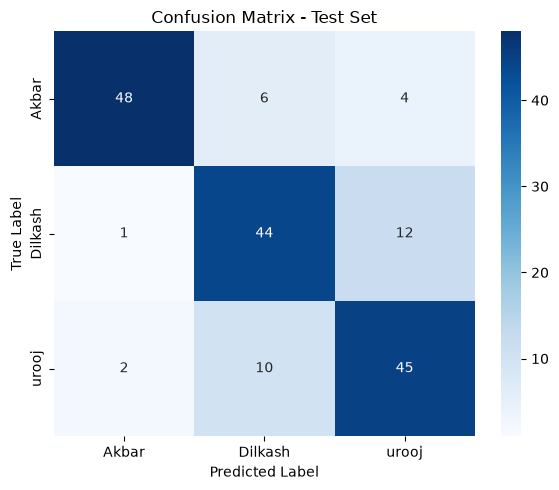


Confusion matrix saved to: results/confusion_matrix.png


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()

# Save for the report
plt.savefig('../results/confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion matrix saved to: results/confusion_matrix.png")

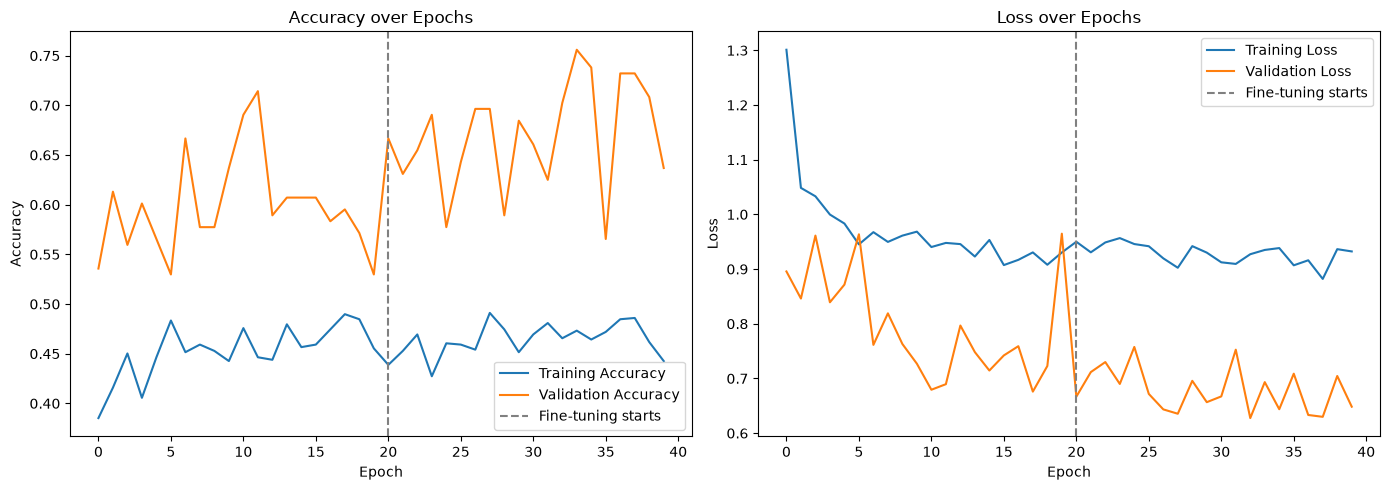

Training curves saved to: results/training_curves.png


In [18]:
# Combine initial training history and fine-tuning history for full picture
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].axvline(x=len(history.history['accuracy']), color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].axvline(x=len(history.history['loss']), color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150)
plt.show()

print("Training curves saved to: results/training_curves.png")